# Producing Signal Events for a specified energy range

This tutorial will show how to produce signal events for a user specified energy range. 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

To start with, the prcedure to begin the analysis is to create a ``Config`` instance, collecting the public dataset collections and to define the source position to carry out the point source analysis. This serves as the backbone for carrying out analysis via SkyLLH. 

In [2]:
from skyllh.core.config import Config

cfg = Config()

In [ ]:
from skyllh.datasets.i3.PublicData_14y_ps import create_dataset_collection

dsc = create_dataset_collection(cfg=cfg)
print(dsc.dataset_names)
datasets = dsc['IC40', 'IC59', 'IC79', 'IC86_I-XI']

The source chosen for this example is NGC 1068. 

In [4]:
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis
from skyllh.core.source_model import PointLikeSource

src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

source = PointLikeSource(ra=np.radians(src_ra), dec=np.radians(src_dec))

The ``create_analysis`` instance can be created with the ``energy_range`` set to a specific energy range. This interanlly sets the energy range for the singal generator. Here in this example, the ``create_analysis``  instance ``ana`` is created with the energy range $10^2\, \text{GeV}$ to $10^3\, \text{GeV}$. 

In the ``create_analysis`` instance, there is also an option to initialise the power law with a specific spectral index. Here in this example the spectral index is fixed at $\gamma_s = 2.0$. This is the power law flux that the signal generator will use.  

In [55]:
ana = create_analysis(cfg=cfg, datasets=datasets, source=source, energy_range=(1e2, 1e3), refplflux_gamma=2.0)

100%|██████████| 136/136 [00:00<00:00, 2145.34it/s]


The ``ana`` instance has a ``generate_signal_events`` proprty. This property can be used to generate or augment signal only pseudo-data. The function takes the ``RandomStateService`` instance, and the mean number of events to generate as its arguments along with a few optional arguments.  

This returns 
1. The actual Number of generated events
2. The list of the number of signal events that have been generated for each data set.
3. The list of instance of DataFieldRecordArray containing the signal data events for each data set. An entry is None, if no signal events were generated for this particular data set.

In [56]:
from skyllh.core.random import RandomStateService

N = 100

rss = RandomStateService(seed=1)
n_sig_erange, n_events_list_erange, events_list_erange = ana.generate_signal_events(rss, N)

It is also possible to change the energy range to generate signal events without having to reinitialise the analysis instance ``ana``. By re-defining ``ana.energy_range``, one can change what ``ana.generate_signal_events()`` uses as the energy range. 

In [57]:
rss = RandomStateService(seed=1)
ana.energy_range = (1e2, 1e9)
n_sig, n_events_list, events_list = ana.generate_signal_events(rss, N)

Here, in this example, the generated events for each database is collected, and the histogram below illustrates that the signal only pseudo-data is correctly generated for the specified energy ranges. 

It is to be noted that the only thing that is being limited is the injected signal: **We inject signals only in that energy range but the signal hypothesis in the likelihood still assumes the full energy range**. 

In [60]:
log_true_energy = np.concatenate([events['log_true_energy'] for events in events_list])

In [62]:
injected_log_true_energy = np.concatenate([events['log_true_energy'] for events in events_list_erange])

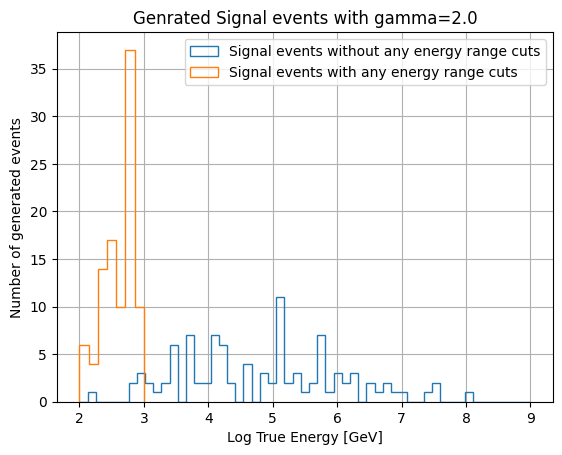

In [ ]:
plt.hist(
    log_true_energy, bins=np.linspace(2, 9, 56), histtype='step', label='Signal events without any energy range cuts'
)
plt.hist(
    injected_log_true_energy,
    bins=np.linspace(2, 3, 8),
    histtype='step',
    label='Signal events with (1e2, 1e3) energy range cut',
)
plt.title('Generated signal events with gamma=2.0')
plt.xlabel('Log True Energy [GeV]')
plt.ylabel('Number of generated events')
plt.grid('True')
plt.legend()
plt.show()